# Colab 05 - Danh gia TEST cuoi cung + SHAP + Report

Buoc cuoi quy trinh data-centric AI. Nap `BEST_PARAMS`/`CHOSEN_THRESHOLD` tu nb04,
**refit Random Forest tren train+val**, danh gia **TEST (`step > 631`) mot lan duy nhat**,
roi **giai thich model bang SHAP** va viet report.


## Setup

In [1]:
# Chay LOCAL. Hoac: pip install duckdb pandas numpy scikit-learn matplotlib shap
%pip install duckdb pandas numpy scikit-learn matplotlib shap numba
print("deps ready")

Note: you may need to restart the kernel to use updated packages.
deps ready


C:\workspace\pit-fintech\.venv\Scripts\python.exe: No module named pip


In [2]:
# === Import data (chay LOCAL): tro thang toi file PaySim CSV tren may =====
# Khong mount Drive, khong upload - chi tro toi file CSV co san tren o cung.
from pathlib import Path

# <<< SUA duong dan CSV cho dung may ban (raw-string r"..." tren Windows) >>>
PAYSIM_CSV = r"C:\workspace\pit-fintech\data\raw\PS_20174392719_1491204439457_log.csv"

# Cache dat canh notebook -> GIU LAI giua cac lan chay (nb02 build, nb03..05 nap lai nhanh).
CACHE_DIR = "_cache"
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

# Fallback: tu do file .csv cung thu muc neu duong dan tren sai.
if not Path(PAYSIM_CSV).exists():
    par = Path(PAYSIM_CSV).parent
    hits = sorted(par.glob("*.csv")) if par.exists() else []
    if hits:
        PAYSIM_CSV = str(hits[0])
        print("Da tu do thay CSV:", PAYSIM_CSV)
    else:
        print("!! Chua thay CSV. Hay sua PAYSIM_CSV cho dung.")

print("PAYSIM_CSV =", PAYSIM_CSV, "| exists:", Path(PAYSIM_CSV).exists())

PAYSIM_CSV = C:\workspace\pit-fintech\data\raw\PS_20174392719_1491204439457_log.csv | exists: True


In [3]:
# === PIT-safe feature module (self-contained, khop hop dong v3 cua repo) ==
# Xay dung dac trung POINT-IN-TIME CORRECT truc tiep tren raw CSV bang DuckDB:
# voi moi giao dich "cutoff", chi doc cac su kien TRUOC do cua CUNG mot nguoi
# nhan (nameDest) trong cac cua so 1h / 24h / 168h. Khong doc so du tai khoan,
# khong doc nhan, khong doc tuong lai -> khong ro ri (leakage).
#
# Pham vi cham diem: type in (CASH_OUT, TRANSFER) va nguoi nhan la KHACH HANG
# (nameDest bat dau bang 'C'). Day dung la noi gian lan PaySim ton tai.
import duckdb
import numpy as np
import pandas as pd

MAX_WINDOW = 168  # cua so lich su rong nhat (gio)

# 2 dac trung request-time + 8 dac trung lich su PIT = 10 (bo v3, ADR-011).
STATIC_FEATURES = ["current_amount", "transaction_type_transfer"]
HISTORY_FEATURES = [
    "pit_prior_count_1h",
    "pit_prior_amount_1h",
    "pit_prior_count_24h",
    "pit_prior_amount_24h",
    "pit_prior_amount_168h",
    "pit_distinct_senders_24h",
    "pit_distinct_senders_168h",
    "pit_steps_since_last_event",
]
ALL_FEATURES = STATIC_FEATURES + HISTORY_FEATURES

# Bo dac trung "deployable" mac dinh (fallback neu chua chay ablation o nb02).
DEPLOYABLE_CORE = [
    "current_amount",
    "transaction_type_transfer",
    "pit_prior_amount_1h",
    "pit_prior_amount_24h",
    "pit_prior_amount_168h",
    "pit_prior_count_1h",
    "pit_prior_count_24h",
]

# 4 cot so du + nhan: TUYET DOI khong duoc lam dac trung dau vao (leakage/label).
FORBIDDEN_INPUTS = [
    "isFraud",
    "isFlaggedFraud",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]

# Ranh gioi split theo thoi gian (step). Fit qua khu -> chon nguong tren val ->
# bao cao 1 lan tren test. Split ngau nhien se ro ri tuong lai.
TRAIN_MAX_STEP = 520
VAL_MAX_STEP = 631

# Walk-forward CV: train step <= cut - embargo, test cua so (cut, cut + width].
DEFAULT_CUTS = (360, 420, 480, 540)
DEFAULT_TEST_WIDTH = 55

SEED = 20_260_727

# MAX_STEPS: dat 1 so nho (vd 200) de chay thu nhanh; None = dung toan bo du lieu.
MAX_STEPS = None


def connect_paysim(csv_path, max_steps=None):
    """Doc CSV bang pandas (bo qua dong hong) roi register vao DuckDB lam view `paysim`.

    Doc bang pandas chiu loi tot hon read_csv_auto cua DuckDB (dong hong -> skip thay vi crash).
    source_row_number = thu tu dong trong file, dung lam tie-break cho PIT.
    """
    df = pd.read_csv(csv_path, on_bad_lines="skip")
    df.insert(0, "source_row_number", range(1, len(df) + 1))
    if max_steps:
        df = df[df["step"] <= int(max_steps)].reset_index(drop=True)
    con = duckdb.connect()
    con.register("paysim", df)
    return con


def pit_feature_sql(relation="paysim"):
    """SQL sinh 1 vector dac trung PIT cho moi cutoff trong pham vi cham diem.

    Self-join theo nameDest, chi lay su kien co s.step trong [c.step-168, c.step-1]
    (chan tren la c.step-1 -> loai het su kien cung step). Moi cua so con lai duoc
    thu hep them bang FILTER. Tien duoc cong o DECIMAL(18,2) de tong on dinh.
    """
    return f"""
    SELECT
        c.nameDest AS destination_entity_id,
        c.source_row_number,
        c.step,
        CAST(c.amount AS DOUBLE) AS current_amount,
        (CASE WHEN c.type = 'TRANSFER' THEN 1.0 ELSE 0.0 END) AS transaction_type_transfer,
        (count(s.source_row_number)
            FILTER (WHERE s.step >= c.step - 1   AND s.step <= c.step - 1))::BIGINT
            AS pit_prior_count_1h,
        coalesce(sum(CAST(s.amount AS DECIMAL(18,2)))
            FILTER (WHERE s.step >= c.step - 1   AND s.step <= c.step - 1), 0.0)::DOUBLE
            AS pit_prior_amount_1h,
        (count(s.source_row_number)
            FILTER (WHERE s.step >= c.step - 24  AND s.step <= c.step - 1))::BIGINT
            AS pit_prior_count_24h,
        coalesce(sum(CAST(s.amount AS DECIMAL(18,2)))
            FILTER (WHERE s.step >= c.step - 24  AND s.step <= c.step - 1), 0.0)::DOUBLE
            AS pit_prior_amount_24h,
        coalesce(sum(CAST(s.amount AS DECIMAL(18,2)))
            FILTER (WHERE s.step >= c.step - 168 AND s.step <= c.step - 1), 0.0)::DOUBLE
            AS pit_prior_amount_168h,
        (count(DISTINCT s.nameOrig)
            FILTER (WHERE s.step >= c.step - 24  AND s.step <= c.step - 1))::BIGINT
            AS pit_distinct_senders_24h,
        (count(DISTINCT s.nameOrig)
            FILTER (WHERE s.step >= c.step - 168 AND s.step <= c.step - 1))::BIGINT
            AS pit_distinct_senders_168h,
        coalesce(
            c.step - (max(s.step) FILTER (WHERE s.step >= c.step - 168 AND s.step <= c.step - 1)),
            999
        )::BIGINT AS pit_steps_since_last_event,
        c.isFraud
    FROM {relation} AS c
    LEFT JOIN {relation} AS s
        ON s.nameDest = c.nameDest
        AND s.step >= c.step - {MAX_WINDOW}
        AND s.step <= c.step - 1
    WHERE c.type IN ('CASH_OUT', 'TRANSFER')
      AND starts_with(c.nameDest, 'C')
    GROUP BY c.nameDest, c.source_row_number, c.step, c.type, c.amount, c.isFraud
    ORDER BY c.step, c.source_row_number
    """


def build_modeling_frame(csv_path=None, max_steps=None, cache_path=None, rebuild=False):
    """Tra ve DataFrame: 10 dac trung + step + isFraud (+ id). Cache ra parquet neu co."""
    if cache_path and (not rebuild) and Path(cache_path).exists():
        print("Nap frame tu cache:", cache_path)
        frame = pd.read_parquet(cache_path)
    else:
        con = connect_paysim(csv_path, max_steps=max_steps)
        print("Dang dung lai dac trung PIT (self-join tren raw CSV)... co the mat vai phut.")
        frame = con.execute(pit_feature_sql("paysim")).df()
        con.close()
        if cache_path:
            frame.to_parquet(cache_path, index=False)
            print("Da cache frame ->", cache_path)
    frame[ALL_FEATURES] = frame[ALL_FEATURES].astype("float64")
    frame["isFraud"] = frame["isFraud"].astype(int)
    return frame


def three_way_temporal_split(frame, train_max=TRAIN_MAX_STEP, val_max=VAL_MAX_STEP):
    """train step<=train_max / val (train_max, val_max] / test step>val_max."""
    return {
        "train": frame[frame["step"] <= train_max],
        "val": frame[(frame["step"] > train_max) & (frame["step"] <= val_max)],
        "test": frame[frame["step"] > val_max],
    }


def walk_forward_folds(frame, cuts=DEFAULT_CUTS, test_width=DEFAULT_TEST_WIDTH, embargo=0):
    """Danh sach fold walk-forward theo step; moi phan tu la (cut, train_df, test_df)."""
    folds = []
    for cut in cuts:
        train = frame[frame["step"] <= cut - embargo]
        test = frame[(frame["step"] > cut) & (frame["step"] <= cut + test_width)]
        usable = len(train) > 0 and len(test) > 0 and test["isFraud"].nunique() == 2
        folds.append(
            {"cut": cut, "embargo": embargo, "train": train, "test": test, "usable": usable}
        )
    return folds


print("Feature module loaded. ALL_FEATURES =", ALL_FEATURES)

Feature module loaded. ALL_FEATURES = ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_count_24h', 'pit_prior_amount_24h', 'pit_prior_amount_168h', 'pit_distinct_senders_24h', 'pit_distinct_senders_168h', 'pit_steps_since_last_event']


In [4]:
# === Doc/ghi bo dac trung da chot o nb02 (handoff giua cac notebook) ======
import json

SELECTED_FEATURES_JSON = str(Path(CACHE_DIR) / "selected_features.json")


def save_selected_features(features, source="nb02-ablation"):
    Path(SELECTED_FEATURES_JSON).write_text(
        json.dumps({"features": list(features), "source": source}, indent=2), encoding="utf-8"
    )
    print("Da ghi selected features ->", SELECTED_FEATURES_JSON)


def load_selected_features(fallback=None):
    chosen = list(fallback) if fallback is not None else list(DEPLOYABLE_CORE)
    if Path(SELECTED_FEATURES_JSON).exists():
        got = json.loads(Path(SELECTED_FEATURES_JSON).read_text(encoding="utf-8")).get("features")
        if got:
            chosen = list(got)
    return chosen

In [5]:
# === Random Forest: 1 factory dung chung cho moi notebook =================
from sklearn.ensemble import RandomForestClassifier


def make_rf(params=None, seed=SEED):
    base = dict(
        n_estimators=25,     # chay thu nhanh (nb05 standalone, khong can nb04); tang lai khi final
        max_depth=16,          # chan cay sau vo han -> nhanh hon nhieu, bot overfit
        min_samples_leaf=20,   # la to hon -> cay nong, nhanh
        min_samples_split=2,
        max_features="sqrt",
        max_samples=0.3,       # moi cay chi bootstrap ~30% du lieu -> ~3x nhanh
        class_weight="balanced_subsample",  # bu lech lop cuc doan cua fraud
        n_jobs=-1,
        random_state=seed,
    )
    if params:
        base.update(params)
    return RandomForestClassifier(**base)


In [6]:
FRAME_CACHE = str(Path(CACHE_DIR) / "modeling_frame.parquet")
frame = build_modeling_frame(PAYSIM_CSV, max_steps=MAX_STEPS, cache_path=FRAME_CACHE, rebuild=False)

tuning_path = Path(CACHE_DIR) / "tuning.json"
if tuning_path.exists():
    tuning = json.loads(tuning_path.read_text(encoding="utf-8"))
    BEST_PARAMS = tuning["best_params"]
    CHOSEN_THRESHOLD = tuning["chosen_threshold"]
    FEATURES = tuning["features"]
else:  # fallback neu chua chay nb04
    BEST_PARAMS, CHOSEN_THRESHOLD = {}, None
    FEATURES = load_selected_features(DEPLOYABLE_CORE)
print("FEATURES:", FEATURES)
print("BEST_PARAMS:", BEST_PARAMS)
print("CHOSEN_THRESHOLD:", CHOSEN_THRESHOLD)

Nap frame tu cache: _cache\modeling_frame.parquet
FEATURES: ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_count_24h', 'pit_prior_amount_24h', 'pit_prior_amount_168h', 'pit_distinct_senders_24h', 'pit_distinct_senders_168h', 'pit_steps_since_last_event']
BEST_PARAMS: {'max_depth': 12, 'min_samples_leaf': 35, 'max_features': 'log2', 'n_estimators': 25}
CHOSEN_THRESHOLD: 0.8678141144337146


## Refit tren train+val, chon nguong out-of-sample neu thieu

In [7]:
from sklearn.metrics import roc_curve

splits = three_way_temporal_split(frame)
train_val = frame[frame["step"] <= VAL_MAX_STEP]

if CHOSEN_THRESHOLD is None:
    # Train tren train-only, chon nguong @FPR=1% tren VAL.
    tmp = make_rf(BEST_PARAMS)
    tmp.fit(splits["train"][FEATURES], splits["train"]["isFraud"])
    yv = splits["val"]["isFraud"].to_numpy()
    pv = tmp.predict_proba(splits["val"][FEATURES])[:, 1]
    fpr, tpr, thr = roc_curve(yv, pv)
    CHOSEN_THRESHOLD = float(thr[int(np.argmin(np.abs(fpr - 0.01)))])
    print("CHOSEN_THRESHOLD (auto @FPR=1%) =", round(CHOSEN_THRESHOLD, 5))

final_model = make_rf(BEST_PARAMS)
final_model.fit(train_val[FEATURES], train_val["isFraud"])
print("Da refit final_model tren train+val:", train_val.shape)

Da refit final_model tren train+val: (2732430, 14)


## Part A - Danh gia TEST (mot lan duy nhat)

In [8]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
)

test = splits["test"]
ytest = test["isFraud"].to_numpy()
ptest = final_model.predict_proba(test[FEATURES])[:, 1]
pred = (ptest >= CHOSEN_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(ytest, pred).ravel()
prev = float(ytest.mean())
prec = tp / (tp + fp) if (tp + fp) else 0.0
rec = tp / (tp + fn) if (tp + fn) else 0.0

test_report = {
    "test_rows": len(ytest),
    "test_frauds": int(ytest.sum()),
    "prevalence": round(prev, 6),
    "pr_auc": round(average_precision_score(ytest, ptest), 6),
    "roc_auc": round(roc_auc_score(ytest, ptest), 6),
    "brier": round(brier_score_loss(ytest, ptest), 6),
    "threshold": round(CHOSEN_THRESHOLD, 5),
    "TP": int(tp),
    "FP": int(fp),
    "FN": int(fn),
    "TN": int(tn),
    "precision": round(prec, 4),
    "recall": round(rec, 4),
    "pr_auc_lift_vs_random": round(average_precision_score(ytest, ptest) / prev, 2),
}
display(pd.DataFrame([test_report]))

,test_rows,test_frauds,prevalence,pr_auc,roc_auc,brier,threshold,TP,FP,FN,TN,precision,recall,pr_auc_lift_vs_random
0,37979,1252,0.032966,0.317233,0.808628,0.21262,0.86781,685,4468,567,32259,0.1329,0.5471,9.62


### Cach doc

So `pr_auc` voi `prevalence` (san ngau nhien). `FP` = so khach sach bi chan nham -> chi phi
van hanh. `recall` = ti le vu fraud bat duoc. PR-AUC tut sau khi bo leakage la ket qua **hop le**.


## Part B - SHAP: model bat fraud dua vao feature nao?

In [9]:
import sys, importlib.util
print("Kernel python :", sys.executable)
for mod in ("numba", "llvmlite", "shap"):
    spec = importlib.util.find_spec(mod)
    if spec:
        m = __import__(mod)
        print(f"{mod:9s}: FOUND  v={getattr(m,'__version__','?'):12s} @ {spec.origin}")
    else:
        print(f"{mod:9s}: NOT FOUND")

Kernel python : C:\workspace\pit-fintech\.venv\Scripts\python.exe
numba    : FOUND  v=0.67.0       @ C:\workspace\pit-fintech\.venv\Lib\site-packages\numba\__init__.py
llvmlite : FOUND  v=0.49.0       @ C:\workspace\pit-fintech\.venv\Lib\site-packages\llvmlite\__init__.py


C:\workspace\pit-fintech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap     : FOUND  v=0.51.0       @ C:\workspace\pit-fintech\.venv\Lib\site-packages\shap\__init__.py


In [10]:
import shap

rng = np.random.default_rng(SEED)
Xtest = test[FEATURES].reset_index(drop=True)
n = min(2000, len(Xtest))  # SHAP tren RF hoi cham -> lay mau
idx = rng.choice(len(Xtest), size=n, replace=False)
X_shap = Xtest.iloc[idx]

explainer = shap.TreeExplainer(final_model)
sv = explainer.shap_values(X_shap)
# RF classifier: co the tra list [class0, class1] hoac mang 3 chieu -> lay lop 1 (fraud).
if isinstance(sv, list):
    sv_pos = sv[1]
elif getattr(sv, "ndim", 2) == 3:
    sv_pos = sv[:, :, 1]
else:
    sv_pos = sv
print("SHAP values shape:", np.asarray(sv_pos).shape)

SHAP values shape: (2000, 10)


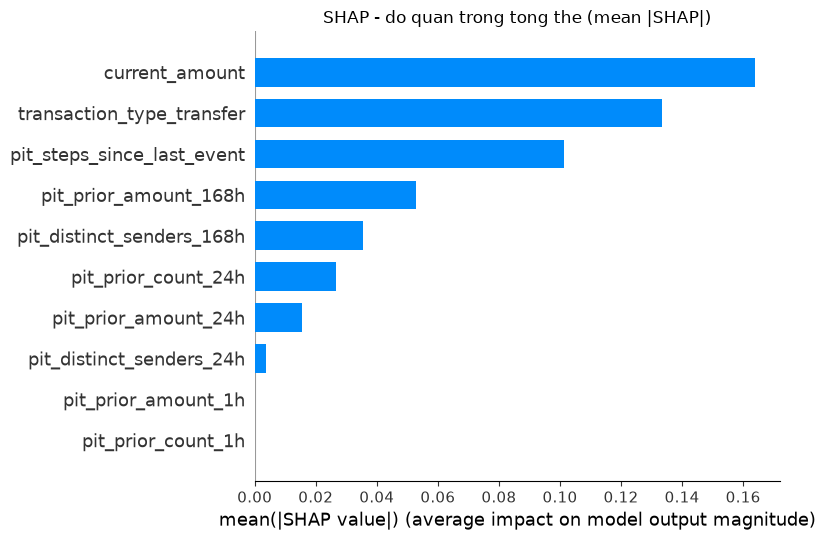

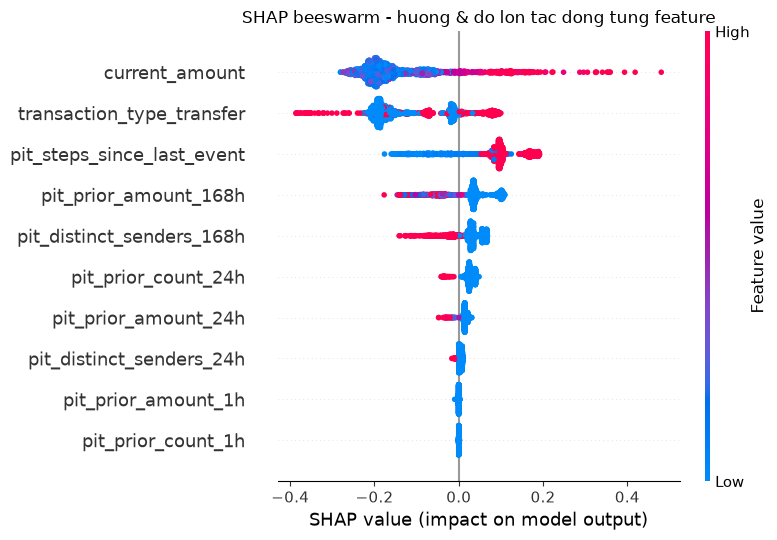

In [11]:
import matplotlib.pyplot as plt

shap.summary_plot(sv_pos, X_shap, plot_type="bar", show=False)
plt.title("SHAP - do quan trong tong the (mean |SHAP|)")
plt.tight_layout()
plt.show()

shap.summary_plot(sv_pos, X_shap, show=False)
plt.title("SHAP beeswarm - huong & do lon tac dong tung feature")
plt.tight_layout()
plt.show()

### Cach doc beeswarm

Feature xep tren cung = anh huong manh nhat. Voi 1 feature: diem do (gia tri cao) nam ben
phai nghia la gia tri cao **day** xac suat fraud len; ben trai la keo xuong.


### Doi chieu 3 nguon importance: SHAP vs impurity (RF) vs permutation

In [12]:
from sklearn.inspection import permutation_importance

mean_abs_shap = np.abs(sv_pos).mean(axis=0)
impurity = final_model.feature_importances_
perm = permutation_importance(
    final_model,
    splits["val"][FEATURES],
    splits["val"]["isFraud"],
    scoring="average_precision",
    n_repeats=5,
    random_state=SEED,
    n_jobs=-1,
).importances_mean

cmp = pd.DataFrame(
    {
        "feature": FEATURES,
        "shap": mean_abs_shap,
        "impurity": impurity,
        "permutation": perm,
    }
)
for col in ["shap", "impurity", "permutation"]:
    cmp[col + "_rank"] = cmp[col].rank(ascending=False).astype(int)
display(cmp.sort_values("shap", ascending=False).reset_index(drop=True))

,feature,shap,impurity,permutation,shap_rank,impurity_rank,permutation_rank
0,current_amount,0.163865,0.285543,0.228161,1,1,1
1,transaction_type_transfer,0.133432,0.165836,0.166488,2,3,2
2,pit_steps_since_last_event,0.101350,0.225106,0.075928,3,2,3
3,pit_prior_amount_168h,0.052704,0.142277,0.062230,4,4,4
4,pit_distinct_senders_168h,0.035469,0.064602,0.059708,5,5,5
5,pit_prior_count_24h,0.026532,0.051601,0.011222,6,6,6
6,pit_prior_amount_24h,0.015467,0.045182,0.005339,7,7,7
7,pit_distinct_senders_24h,0.003790,0.013658,-0.000027,8,8,9
8,pit_prior_amount_1h,0.000169,0.004598,-0.000101,9,9,10
9,pit_prior_count_1h,0.000074,0.001597,0.000635,10,10,8


### Cach doc bang doi chieu

Feature nao top o **ca ba** cot rank -> chac chan la feature tai tin hieu that. Feature
rank thap ca ba -> ung vien loai bo o vong feature-selection sau.


## Report

In [13]:
print("=" * 60)
print("PAYSIM FRAUD - RANDOM FOREST - FINAL REPORT")
print("=" * 60)
print("Features (", len(FEATURES), "):", FEATURES)
print("Best params:", BEST_PARAMS)
print("Threshold:", round(CHOSEN_THRESHOLD, 5))
print("-" * 60)
for k, v in test_report.items():
    print(f"  {k:24s}: {v}")
print("-" * 60)
top3 = cmp.sort_values("shap", ascending=False)["feature"].head(3).tolist()
print("Top-3 feature (SHAP):", top3)
print("=" * 60)

# Luu report ra Drive.
Path(Path(CACHE_DIR) / "final_report.json").write_text(
    json.dumps(
        {
            "report": test_report,
            "features": FEATURES,
            "best_params": BEST_PARAMS,
            "top3_shap": top3,
        },
        indent=2,
    ),
    encoding="utf-8",
)
print("Da luu ->", str(Path(CACHE_DIR) / "final_report.json"))

PAYSIM FRAUD - RANDOM FOREST - FINAL REPORT
Features ( 10 ): ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_count_24h', 'pit_prior_amount_24h', 'pit_prior_amount_168h', 'pit_distinct_senders_24h', 'pit_distinct_senders_168h', 'pit_steps_since_last_event']
Best params: {'max_depth': 12, 'min_samples_leaf': 35, 'max_features': 'log2', 'n_estimators': 25}
Threshold: 0.86781
------------------------------------------------------------
  test_rows               : 37979
  test_frauds             : 1252
  prevalence              : 0.032966
  pr_auc                  : 0.317233
  roc_auc                 : 0.808628
  brier                   : 0.21262
  threshold               : 0.86781
  TP                      : 685
  FP                      : 4468
  FN                      : 567
  TN                      : 32259
  precision               : 0.1329
  recall                  : 0.5471
  pr_auc_lift_vs_random   : 9.62
------------------------

## Ket luan chuoi notebook

Ban da di het quy trinh **data-centric AI** cho fraud detection voi **Random Forest**,
chay LOCAL tu **raw PaySim CSV**:

1. **EDA** - hieu du lieu, xac dinh cot bi cam (leakage).
2. **Feature engineering + ablation** - dung 10 dac trung PIT-safe, chot bo dac trung.
3. **Walk-forward CV** - do on dinh theo thoi gian + chon nguong.
4. **Tuning** - Optuna toi uu PR-AUC tren CV + nguong quyet dinh.
5. **TEST + SHAP** - danh gia 1 lan + giai thich model + report.

PR-AUC (khong phai accuracy) la thuoc do that; moi danh gia deu **PIT-correct** (khong ro ri).


## MLflow logging (Data-Centric AI)

Ba cell cuoi (chay sau cung, sau khi da chay het notebook): **schema chuan** (giong het moi notebook) + **cell log** rieng cua notebook nay. Log len MLflow chung `http://100.116.36.6:5000`; khong toi duoc thi fallback `./mlruns`.

In [14]:
# ============================================================================
# MLflow logging schema - Data-Centric AI (Andrew Ng). CELL CHUAN, dat O CUOI
# notebook. Copy-paste GIONG HET vao ca 5 notebook colab_01..05.
# Log len MLflow chung (http://100.116.36.6:5000); server khong toi duoc ->
# fallback local ./mlruns. Chua cai mlflow -> notebook van chay, chi khong log.
# ============================================================================
import hashlib
import json as _json
import os
import socket
from datetime import datetime, timezone
from pathlib import Path as _Path

MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://100.116.36.6:5000")
MLFLOW_EXPERIMENT = "paysim-fraud-rf-colab"      # tach khoi track LightGBM cua src/
MLFLOW_LOCAL_FALLBACK = "file:./mlruns"           # dung khi server chung down
REGISTRY_MODEL_NAME = "paysim-fraud-rf"           # CHI nb05 register (RF experimental)


def _mlflow_ready():
    try:
        import mlflow
        import mlflow.sklearn  # noqa: F401
    except ImportError:
        print("[mlflow] chua cai (pip install mlflow) -> notebook van chay, khong log")
        return None
    uri = MLFLOW_TRACKING_URI
    try:  # ping nhanh 2s; server chung khong toi duoc -> fallback local
        netloc = uri.split("//", 1)[-1].split("/", 1)[0]
        host, _, port = netloc.partition(":")
        socket.create_connection((host, int(port or 80)), timeout=2).close()
    except OSError:
        print("[mlflow] %s khong toi duoc -> fallback %s" % (uri, MLFLOW_LOCAL_FALLBACK))
        uri = MLFLOW_LOCAL_FALLBACK
    mlflow.set_tracking_uri(uri)
    mlflow.set_experiment(MLFLOW_EXPERIMENT)
    print("[mlflow] tracking=%s experiment=%s" % (uri, MLFLOW_EXPERIMENT))
    return mlflow


MLFLOW = _mlflow_ready()   # None => moi helper duoi day tu no-op


def data_version(frame=None, csv_path=None):
    """Danh tinh du lieu (Data-Centric): hash prefix CSV + so dong + range step + fraud rate."""
    info = {}
    p = csv_path or globals().get("PAYSIM_CSV")
    if p and _Path(p).exists():
        h = hashlib.sha256()
        with open(p, "rb") as f:
            h.update(f.read(8 * 1024 * 1024))   # 8MB dau -> dinh danh nhanh, on dinh
        info["csv_sha8"] = h.hexdigest()[:8]
        info["csv_bytes"] = _Path(p).stat().st_size
    info["max_steps"] = str(globals().get("MAX_STEPS"))
    if frame is not None and len(frame):
        info["row_count"] = int(len(frame))
        info["step_min"] = int(frame["step"].min())
        info["step_max"] = int(frame["step"].max())
        info["fraud_rate"] = round(float(frame["isFraud"].mean()), 6)
    return info


def start_run(stage, params=None, extra_tags=None):
    if MLFLOW is None:
        return None
    run = MLFLOW.start_run(run_name="%s__%s" % (stage, datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")))
    tags = {"stage": stage, "model_family": "random_forest", "code_source": "colab",
            "primary_metric": "pr_auc", "split_protocol": "temporal_70_15_15",
            "sealed_test_touched": "false"}
    tags.update(extra_tags or {})
    MLFLOW.set_tags(tags)
    if params:
        MLFLOW.log_params({k: v for k, v in params.items() if v is not None})
    return run


def log_metrics(metrics):
    if MLFLOW is None:
        return
    MLFLOW.log_metrics({k: float(v) for k, v in metrics.items() if v is not None})


def log_sliced_pr_auc(y_true, y_score, slices, prefix="pr_auc"):
    """slices = {ten: mask_bool}. Chi log slice co ca 2 lop de PR-AUC co nghia (Data-Centric)."""
    if MLFLOW is None:
        return
    import numpy as np
    from sklearn.metrics import average_precision_score
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    MLFLOW.log_metric(prefix, float(average_precision_score(y_true, y_score)))
    for name, mask in slices.items():
        mask = np.asarray(mask, dtype=bool)
        if mask.sum() and 0 < int(y_true[mask].sum()) < int(mask.sum()):
            MLFLOW.log_metric("%s__%s" % (prefix, name),
                              float(average_precision_score(y_true[mask], y_score[mask])))


def log_json_artifact(obj, filename):
    if MLFLOW is None:
        return
    p = _Path(filename)
    p.write_text(_json.dumps(obj, indent=2, default=str), encoding="utf-8")
    MLFLOW.log_artifact(str(p))


def log_file_artifact(path):
    if MLFLOW is None or not _Path(path).exists():
        return
    MLFLOW.log_artifact(str(path))


def log_error_samples(frame, features, y_true, y_pred, y_score, n=300, filename="error_samples.csv"):
    """Data-Centric error analysis: xuat cac ca sai (FN/FP) de soi lai chat luong du lieu."""
    if MLFLOW is None:
        return
    import numpy as np
    err = frame[list(features)].copy()
    for col in ("destination_entity_id", "step"):
        if col in frame:
            err[col] = frame[col].to_numpy()
    err["y_true"] = np.asarray(y_true)
    err["y_pred"] = np.asarray(y_pred)
    err["y_score"] = np.asarray(y_score)
    err = err[err["y_true"] != err["y_pred"]].sort_values("y_score", ascending=False).head(n)
    p = _Path(filename)
    err.to_csv(p, index=False)
    MLFLOW.log_artifact(str(p))
    print("[mlflow] error_samples: %d ca sai -> %s" % (len(err), filename))


def log_sklearn_model(model, register=False, artifact_path="model"):
    """Log RF; register=True -> tao model version tren Model Registry (chi nb05)."""
    if MLFLOW is None:
        return None
    name = REGISTRY_MODEL_NAME if register else None
    try:  # mlflow >=2.20/3 dung name=; ban cu dung artifact_path=
        info = MLFLOW.sklearn.log_model(model, name=artifact_path, registered_model_name=name)
    except TypeError:
        info = MLFLOW.sklearn.log_model(model, artifact_path=artifact_path, registered_model_name=name)
    if register:
        print("[mlflow] registered '%s' <- %s" % (REGISTRY_MODEL_NAME, getattr(info, "model_uri", "?")))
    return info


def log_rf_evaluation(stage, model, y_true, y_pred, features=None, y_score=None,
                      threshold=0.5, params=None, extra_tags=None, register=False):
    """Log 1 danh gia RF DAY DU cho MLflow (truc quan hon confusion don thuan):
    confusion tn/fp/fn/tp + precision/recall/f1/accuracy + pr_auc/roc_auc (neu co y_score)
    + threshold + feature gain (feature_importances_). register=True -> dang ky model."""
    if MLFLOW is None:
        print("[mlflow] skipped RF evaluation: tracking unavailable")
        return None
    import numpy as np
    from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                                 precision_score, recall_score)

    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics = {"confusion_tn": int(tn), "confusion_fp": int(fp),
               "confusion_fn": int(fn), "confusion_tp": int(tp),
               "precision": precision_score(y_true, y_pred, zero_division=0),
               "recall": recall_score(y_true, y_pred, zero_division=0),
               "f1": f1_score(y_true, y_pred, zero_division=0),
               "accuracy": accuracy_score(y_true, y_pred)}
    if y_score is not None and 0 < int(y_true.sum()) < len(y_true):
        from sklearn.metrics import average_precision_score, roc_auc_score
        y_score = np.asarray(y_score, dtype=float)
        metrics["pr_auc"] = average_precision_score(y_true, y_score)
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    gain = {}
    imp = getattr(model, "feature_importances_", None)
    if imp is not None and features is not None and len(features) == len(imp):
        gain = {str(f): float(g) for f, g in zip(features, imp)}
    run_params = {"threshold": float(threshold), "n_rows_evaluated": int(len(y_true)),
                  "n_features": int(getattr(model, "n_features_in_", len(features or []))),
                  "rf_n_estimators": int(model.get_params().get("n_estimators", 0)),
                  "rf_max_depth": model.get_params().get("max_depth"),
                  "rf_max_samples": model.get_params().get("max_samples"),
                  "rf_min_samples_leaf": model.get_params().get("min_samples_leaf"),
                  "rf_random_state": model.get_params().get("random_state")}
    run_params.update(params or {})
    tags = {"stage": stage, "model_family": "random_forest",
            "metric_contract": "full_eval", "code_source": "colab",
            "sealed_test_touched": "false"}
    tags.update(extra_tags or {})
    artifact = {"labels": [0, 1], "threshold": float(threshold),
                "matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
                "metrics": {k: float(v) for k, v in metrics.items()},
                "feature_gain": dict(sorted(gain.items(), key=lambda kv: kv[1], reverse=True))}
    with MLFLOW.start_run(run_name="rf__%s" % stage):
        MLFLOW.set_tags(tags)
        MLFLOW.log_params({k: v for k, v in run_params.items() if v is not None})
        MLFLOW.log_metrics({k: float(v) for k, v in metrics.items()})
        if gain:
            MLFLOW.log_metrics({"gain__%s" % f: g for f, g in gain.items()})
        log_json_artifact(artifact, "evaluation_%s.json" % stage)
        log_sklearn_model(model, register=register, artifact_path="model")
        run_id = MLFLOW.active_run().info.run_id
    _msg = "P=%.3f R=%.3f F1=%.3f" % (metrics["precision"], metrics["recall"], metrics["f1"])
    if "pr_auc" in metrics:
        _msg += " PR-AUC=%.4f" % metrics["pr_auc"]
    print("[mlflow] RF eval logged stage=%s run=%s %s" % (stage, run_id, _msg))
    return {**metrics, "run_id": run_id}


def end_run():
    if MLFLOW is not None:
        MLFLOW.end_run()


[mlflow] tracking=http://100.116.36.6:5000 experiment=paysim-fraud-rf-colab


In [15]:
# --- MLflow: log RF DAY DU + REGISTER (final test, Step 2 qua validation) ---
if MLFLOW is not None:
    log_rf_evaluation(
        "nb05_final_rf_test", final_model, ytest, pred, features=FEATURES, y_score=ptest,
        threshold=round(float(CHOSEN_THRESHOLD), 6), register=True,
        params={"split": "temporal_test"},
        extra_tags={"notebook": "colab_05_shap_report", "sealed_test_touched": "true"},
    )


2026/08/24 21:38:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'paysim-fraud-rf' already exists. Creating a new version of this model...
2026/08/24 21:38:32 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: paysim-fraud-rf, version 2
Created version '2' of model 'paysim-fraud-rf'.


[mlflow] registered 'paysim-fraud-rf' <- models:/m-45a30c31a13e44fda25da2884a3bb566
🏃 View run rf__nb05_final_rf_test at: http://100.116.36.6:5000/#/experiments/2/runs/dee9fb2dd49d4f79b3662d40ac27e648
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/2
[mlflow] RF eval logged stage=nb05_final_rf_test run=dee9fb2dd49d4f79b3662d40ac27e648 P=0.133 R=0.547 F1=0.214 PR-AUC=0.3172
